# xW Project Notebook

This notebook contains the full COM328 project code, the formatted questions, and the written answers in one file. The only external collection step is `scrape.R`, which saves `train.parquet` and `test.parquet` in `xW/data`. You can find the source code for `scrape.R` in the GitHub [repository](https://github.com/RentoSaijo/COM328/tree/main/xW/scrape.R).

0. Notebook Setup: This section defines all imports, helper functions, data-processing code, unsupervised-learning code, and modeling code directly inside the notebook so the project stays self-contained. The notebook first looks for cached outputs in `xW/outputs` and `xW/cache`; if they are not present, it recomputes the analysis from the parquet files. We run these first because to do this in the middle of each of the questions would be a very long and hard-to-read; we wanted the actual question parts to be a readable chunk of code by processing the data beforehand. The actual project questions and answers begin right after this setup section.

In [25]:
# Load libraries and define all notebook helpers.
import json
import math
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
import optuna
import umap
import xgboost as xgb
from tensorflow import keras

# Match the wide outputs.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (8, 6)

# Keep all paths relative to the `xW` working directory.
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
CACHE_DIR = BASE_DIR / 'cache'
OUTPUT_DIR = BASE_DIR / 'outputs'
CACHE_DIR.mkdir(exist_ok = True)
OUTPUT_DIR.mkdir(exist_ok = True)

# Store the project-wide constants in one place so the later analysis reuses them.
RANDOM_SEED = 328
EVENT_CAP = 180
KEEP_TYPES = [
    'faceoff', 'hit', 'shot-on-goal', 'giveaway',
    'missed-shot', 'blocked-shot', 'goal', 'takeaway',
    'failed-shot-attempt'
]
MODEL_EVENT_TYPES = [
    'blocked-shot', 'faceoff', 'giveaway', 'hit',
    'missed-shot', 'shot-on-goal', 'takeaway'
]
RAW_COLUMNS = [
    'gameId', 'eventId', 'sortOrder', 'secondsElapsedInGame',
    'eventOwnerTeamId', 'isHome', 'eventTypeDescKey', 'situationCode',
    'xCoordNorm', 'yCoordNorm', 'homeGoals', 'awayGoals'
]


def set_seed(seed = RANDOM_SEED):
    # Reuse the same seed everywhere so the notebook is reproducible.
    random.seed(seed)
    np.random.seed(seed)
    keras.utils.set_random_seed(seed)


def clean_situation(code):
    # Convert situation codes into consistent 4-character strings such as 0651.
    if pd.isna(code):
        return '0000'
    text = str(code)
    if text.endswith('.0'):
        text = text[:-2]
    return text.zfill(4)


def reorder_situation_by_owner(code, owner_is_home):
    # Reorder the raw code into (event owner goalie, event owner skaters, opponent skaters, opponent goalie).
    away_goalie, away_skaters, home_skaters, home_goalie = list(clean_situation(code))
    if owner_is_home:
        return f'{home_goalie}{home_skaters}{away_skaters}{away_goalie}'
    return f'{away_goalie}{away_skaters}{home_skaters}{home_goalie}'


def load_raw_split(split):
    # Read only the columns needed for the project pipeline.
    return pd.read_parquet(DATA_DIR / f'{split}.parquet', columns = RAW_COLUMNS)


def prepare_filtered_events(df):
    # Keep only the event types used in the project and normalize the event representation.
    filt = df[df['eventTypeDescKey'].isin(KEEP_TYPES)].copy()
    filt['eventTypeModel'] = filt['eventTypeDescKey'].replace({'goal': 'shot-on-goal'})
    filt['situationOwner'] = [
        reorder_situation_by_owner(code, bool(owner_is_home))
        for code, owner_is_home in zip(filt['situationCode'], filt['isHome'])
    ]
    filt['xCoordNorm'] = filt['xCoordNorm'].fillna(0.0)
    filt['yCoordNorm'] = filt['yCoordNorm'].fillna(0.0)
    filt = filt.sort_values(['gameId', 'secondsElapsedInGame', 'sortOrder', 'eventId']).reset_index(drop = True)
    counts = filt.groupby('gameId').size()
    return filt, counts


def select_evenly_spaced_events(game_events, cap = EVENT_CAP):
    # Sample across the full game so the fixed-width row still captures early, middle, and late context.
    if len(game_events) == cap:
        return game_events.copy()
    idx = np.floor(np.linspace(0, len(game_events), cap, endpoint = False)).astype(int)
    return game_events.iloc[idx].copy()


def build_wide_split(split, cap = EVENT_CAP):
    # Cache the expensive widening step because every later section reuses the same matrix.
    cache_path = CACHE_DIR / f'wide_{split}.parquet'
    if cache_path.exists():
        return pd.read_parquet(cache_path)
    raw = load_raw_split(split)
    filt, counts = prepare_filtered_events(raw)
    keep_games = counts[counts >= cap].index
    filt = filt[filt['gameId'].isin(keep_games)]
    raw_scores = raw.groupby('gameId')[['homeGoals', 'awayGoals']].max()
    rows = []
    for game_id, g in filt.groupby('gameId', sort = False):
        g = select_evenly_spaced_events(g, cap = cap)
        home_team = int(g.loc[g['isHome'] == True, 'eventOwnerTeamId'].iloc[0])
        away_team = int(g.loc[g['isHome'] == False, 'eventOwnerTeamId'].iloc[0])
        final_home = int(raw_scores.loc[game_id, 'homeGoals'])
        final_away = int(raw_scores.loc[game_id, 'awayGoals'])

        event_owner = g['eventOwnerTeamId'].to_numpy(dtype = np.int64)
        event_times = g['secondsElapsedInGame'].to_numpy(dtype = np.float32)
        event_x = g['xCoordNorm'].to_numpy(dtype = np.float32)
        event_y = g['yCoordNorm'].to_numpy(dtype = np.float32)
        event_types = g['eventTypeModel'].astype(str).to_numpy()
        event_situations = g['situationOwner'].astype(str).to_numpy()
        # Duplicate each game into one row per team so the response is team-centric.
        row_specs = [
            (home_team, away_team, 1, int(final_home > final_away), final_home, final_away),
            (away_team, home_team, 0, int(final_away > final_home), final_away, final_home),
        ]
        for team_id, opponent_id, is_home_team, won, goals_for, goals_against in row_specs:
            row = [game_id, team_id, opponent_id, is_home_team, goals_for, goals_against, won]
            # `isOwner` is the field that tells us whether the row's team caused a given event.
            event_owner_flag = (event_owner == team_id).astype(np.int8)
            for i in range(cap):
                row.extend([
                    int(event_owner_flag[i]),
                    event_situations[i],
                    float(event_times[i]),
                    float(event_x[i]),
                    float(event_y[i]),
                    event_types[i],
                ])
            rows.append(row)
    cols = ['gameId', 'teamId', 'opponentTeamId', 'isHomeTeam', 'goalsFor', 'goalsAgainst', 'won']
    for i in range(1, cap + 1):
        cols.extend([
            f'event_{i}_isOwner',
            f'event_{i}_situation',
            f'event_{i}_time',
            f'event_{i}_xNorm',
            f'event_{i}_yNorm',
            f'event_{i}_type',
        ])
    wide = pd.DataFrame(rows, columns = cols)
    wide.to_parquet(cache_path, index = False)
    return wide


def build_all_wide(cap = EVENT_CAP):
    return build_wide_split('train', cap = cap), build_wide_split('test', cap = cap)


def build_feature_maps(train_wide, test_wide, cap = EVENT_CAP):
    # Build integer maps from the observed categorical levels so the models can use them numerically.
    situation_cols = [f'event_{i}_situation' for i in range(1, cap + 1)]
    train_situations = pd.unique(train_wide[situation_cols].to_numpy().ravel())
    test_situations = pd.unique(test_wide[situation_cols].to_numpy().ravel())
    situation_levels = sorted(set(train_situations).union(set(test_situations)))
    return {
        'situation': {value: idx + 1 for idx, value in enumerate(situation_levels)},
        'type': {value: idx + 1 for idx, value in enumerate(MODEL_EVENT_TYPES)},
    }


def encode_wide_split(wide, feature_maps, cap = EVENT_CAP):
    # Create both the flat table and the sequence tensors from the same widened rows.
    encoded = wide.copy()
    numeric_seq = np.zeros((len(wide), cap, 4), dtype = np.float32)
    type_seq = np.zeros((len(wide), cap), dtype = np.int32)
    situation_seq = np.zeros((len(wide), cap), dtype = np.int32)
    for i in range(1, cap + 1):
        is_owner_col = f'event_{i}_isOwner'
        situation_col = f'event_{i}_situation'
        time_col = f'event_{i}_time'
        x_col = f'event_{i}_xNorm'
        y_col = f'event_{i}_yNorm'
        type_col = f'event_{i}_type'
        encoded[situation_col] = encoded[situation_col].map(feature_maps['situation']).astype(np.int32)
        encoded[type_col] = encoded[type_col].map(feature_maps['type']).astype(np.int32)
        encoded[is_owner_col] = encoded[is_owner_col].astype(np.int8)
        encoded[time_col] = encoded[time_col].astype(np.float32)
        encoded[x_col] = encoded[x_col].astype(np.float32)
        encoded[y_col] = encoded[y_col].astype(np.float32)
        numeric_seq[:, i - 1, 0] = encoded[is_owner_col].to_numpy(dtype = np.float32)
        numeric_seq[:, i - 1, 1] = encoded[time_col].to_numpy(dtype = np.float32)
        numeric_seq[:, i - 1, 2] = encoded[x_col].to_numpy(dtype = np.float32)
        numeric_seq[:, i - 1, 3] = encoded[y_col].to_numpy(dtype = np.float32)
        type_seq[:, i - 1] = encoded[type_col].to_numpy(dtype = np.int32)
        situation_seq[:, i - 1] = encoded[situation_col].to_numpy(dtype = np.int32)
    return encoded, numeric_seq, type_seq, situation_seq


def build_encoded_datasets(cap = EVENT_CAP):
    # Package every representation once so the rest of the notebook can reuse them.
    train_wide, test_wide = build_all_wide(cap = cap)
    feature_maps = build_feature_maps(train_wide, test_wide, cap = cap)
    train_encoded, train_num_seq, train_type_seq, train_sit_seq = encode_wide_split(train_wide, feature_maps, cap = cap)
    test_encoded, test_num_seq, test_type_seq, test_sit_seq = encode_wide_split(test_wide, feature_maps, cap = cap)
    return {
        'train_wide': train_wide,
        'test_wide': test_wide,
        'train_encoded': train_encoded,
        'test_encoded': test_encoded,
        'train_num_seq': train_num_seq,
        'test_num_seq': test_num_seq,
        'train_type_seq': train_type_seq,
        'test_type_seq': test_type_seq,
        'train_sit_seq': train_sit_seq,
        'test_sit_seq': test_sit_seq,
        'feature_maps': feature_maps,
    }


def split_train_validation(data, validation_size = 0.2):
    # Split by game id so the paired team rows from one game do not leak across train and validation.
    groups = data['train_encoded']['gameId'].to_numpy()
    splitter = GroupShuffleSplit(n_splits = 1, test_size = validation_size, random_state = RANDOM_SEED)
    train_idx, val_idx = next(splitter.split(data['train_encoded'], data['train_encoded']['won'].to_numpy(), groups = groups))
    return {'train_idx': train_idx, 'val_idx': val_idx}


def get_flat_feature_columns(cap = EVENT_CAP):
    cols = []
    for i in range(1, cap + 1):
        cols.extend([
            f'event_{i}_isOwner',
            f'event_{i}_situation',
            f'event_{i}_time',
            f'event_{i}_xNorm',
            f'event_{i}_yNorm',
            f'event_{i}_type',
        ])
    return cols


def classification_summary(y_true, y_prob, threshold = 0.5):
    # Collect the exact classification outputs we will report in the written answers.
    y_pred = (y_prob >= threshold).astype(np.int32)
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division = 0)),
        'recall': float(recall_score(y_true, y_pred, zero_division = 0)),
        'f1': float(f1_score(y_true, y_pred, zero_division = 0)),
        'auc': float(roc_auc_score(y_true, y_prob)),
        'logloss': float(log_loss(y_true, y_prob)),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
        'threshold': float(threshold),
    }


def run_pca_umap_analysis(data, cap = EVENT_CAP):
    # Use the flattened representation for the unsupervised part because PCA and UMAP both expect tabular input.
    flat_cols = get_flat_feature_columns(cap = cap)
    X_train = data['train_encoded'][flat_cols].to_numpy(dtype = np.float32)
    y_train = data['train_encoded']['won'].to_numpy(dtype = np.int32)
    # Standardize before PCA/UMAP so scale differences do not dominate the manifold.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    pca_full = PCA(svd_solver = 'full', random_state = RANDOM_SEED)
    pca_full.fit(X_scaled)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)
    n90 = int(np.searchsorted(cum_var, 0.90) + 1)
    pca_2 = PCA(n_components = 2, random_state = RANDOM_SEED)
    pca_emb = pca_2.fit_transform(X_scaled)
    umap_model = umap.UMAP(
        n_components = 2,
        n_neighbors = 30,
        min_dist = 0.1,
        metric = 'euclidean',
        random_state = RANDOM_SEED,
    )
    umap_emb = umap_model.fit_transform(X_scaled)
    cluster_scores = []
    best_model = None
    best_score = -np.inf
    best_k = None
    # Compare several `k` values and keep the one with the best silhouette score.
    for k in range(2, 9):
        model = KMeans(init = 'k-means++', n_clusters = k, n_init = 10, random_state = RANDOM_SEED)
        labels = model.fit_predict(umap_emb)
        sil = silhouette_score(umap_emb, labels)
        cluster_scores.append({'k': int(k), 'silhouette': float(sil)})
        if sil > best_score:
            best_score = sil
            best_model = model
            best_k = k
    cluster_labels = best_model.labels_
    cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
    cluster_win_rates = pd.DataFrame({'cluster': cluster_labels, 'won': y_train}).groupby('cluster')['won'].mean().sort_index()
    np.save(OUTPUT_DIR / 'pca_2_embedding.npy', pca_emb)
    np.save(OUTPUT_DIR / 'umap_2_embedding.npy', umap_emb)
    return {
        'n_components_90': int(n90),
        'pca_2_variance': [float(x) for x in pca_2.explained_variance_ratio_],
        'cluster_scores': cluster_scores,
        'best_k': int(best_k),
        'best_silhouette': float(best_score),
        'cluster_sizes': {str(int(k)): int(v) for k, v in cluster_sizes.items()},
        'cluster_win_rates': {str(int(k)): float(v) for k, v in cluster_win_rates.items()},
        'umap_noise_proxy': float(1.0 - best_score),
    }


def run_xgboost_optuna(data, split_idx, cap = EVENT_CAP):
    # Train a flattened baseline and tune it with Optuna instead of hand-picking the tree settings.
    flat_cols = get_flat_feature_columns(cap = cap)
    X_train_all = data['train_encoded'][flat_cols].to_numpy(dtype = np.float32)
    y_train_all = data['train_encoded']['won'].to_numpy(dtype = np.int32)
    X_test = data['test_encoded'][flat_cols].to_numpy(dtype = np.float32)
    y_test = data['test_encoded']['won'].to_numpy(dtype = np.int32)
    train_idx = split_idx['train_idx']
    val_idx = split_idx['val_idx']
    X_train = X_train_all[train_idx]
    y_train = y_train_all[train_idx]
    X_val = X_train_all[val_idx]
    y_val = y_train_all[val_idx]
    def objective(trial):
        # Restrict the search to class-style tree parameters and score by validation AUC.
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'tree_method': 'hist',
            'random_state': RANDOM_SEED,
            'n_estimators': trial.suggest_int('n_estimators', 200, 800),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log = True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log = True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log = True),
            'gamma': trial.suggest_float('gamma', 1e-4, 2.0, log = True),
        }
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set = [(X_val, y_val)], verbose = False)
        val_prob = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, val_prob)
    study = optuna.create_study(direction = 'maximize', sampler = optuna.samplers.TPESampler(seed = RANDOM_SEED))
    study.optimize(objective, n_trials = 20, show_progress_bar = False)
    # Refit the best XGBoost model on all training rows before evaluating the held-out season.
    best_params = {
        **study.best_params,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'tree_method': 'hist',
        'random_state': RANDOM_SEED,
    }
    best_model = xgb.XGBClassifier(**best_params)
    best_model.fit(X_train_all, y_train_all, verbose = False)
    test_prob = best_model.predict_proba(X_test)[:, 1]
    metrics = classification_summary(y_test, test_prob)
    top_gain = best_model.get_booster().get_score(importance_type = 'gain')
    top_gain = sorted(top_gain.items(), key = lambda kv: kv[1], reverse = True)[:10]
    return {
        'best_value_auc': float(study.best_value),
        'best_params': best_params,
        'test_metrics': metrics,
        'top_gain_features': top_gain,
    }


def build_sequence_model(num_features, type_vocab, sit_vocab, cap = EVENT_CAP):
    # Keep the network compact: embed the categorical channels, then learn local event patterns with Conv1D layers.
    num_input = keras.Input(shape = (cap, num_features), name = 'num_input')
    type_input = keras.Input(shape = (cap,), dtype = 'int32', name = 'type_input')
    sit_input = keras.Input(shape = (cap,), dtype = 'int32', name = 'sit_input')
    type_emb = keras.layers.Embedding(type_vocab + 1, 4, name = 'type_embedding')(type_input)
    sit_emb = keras.layers.Embedding(sit_vocab + 1, 8, name = 'situation_embedding')(sit_input)
    x = keras.layers.Concatenate(axis = -1)([num_input, type_emb, sit_emb])
    x = keras.layers.Conv1D(32, kernel_size = 5, padding = 'same', activation = 'relu')(x)
    x = keras.layers.MaxPooling1D(pool_size = 2)(x)
    x = keras.layers.Conv1D(32, kernel_size = 5, padding = 'same', activation = 'relu')(x)
    x = keras.layers.GlobalMaxPooling1D()(x)
    x = keras.layers.Dense(32, activation = 'relu')(x)
    x = keras.layers.Dropout(0.2)(x)
    out = keras.layers.Dense(1, activation = 'sigmoid')(x)
    model = keras.Model(inputs = [num_input, type_input, sit_input], outputs = out)
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
        loss = 'binary_crossentropy',
        metrics = [
            keras.metrics.BinaryAccuracy(name = 'accuracy'),
            keras.metrics.AUC(name = 'auc'),
        ],
    )
    return model


def run_neural_sequence(data, split_idx):
    # Standardize only the numeric sequence channels and leave the categorical ids for the embeddings.
    num_train = data['train_num_seq'].copy()
    num_test = data['test_num_seq'].copy()
    y_train_all = data['train_encoded']['won'].to_numpy(dtype = np.int32)
    y_test = data['test_encoded']['won'].to_numpy(dtype = np.int32)
    train_idx = split_idx['train_idx']
    val_idx = split_idx['val_idx']
    train_num = num_train[train_idx]
    val_num = num_train[val_idx]
    test_num = num_test
    mean = train_num.reshape(-1, train_num.shape[-1]).mean(axis = 0)
    std = train_num.reshape(-1, train_num.shape[-1]).std(axis = 0)
    std[std == 0.0] = 1.0
    train_num = (train_num - mean) / std
    val_num = (val_num - mean) / std
    test_num = (test_num - mean) / std
    full_train_num = (num_train - mean) / std
    train_type = data['train_type_seq'][train_idx]
    val_type = data['train_type_seq'][val_idx]
    test_type = data['test_type_seq']
    full_train_type = data['train_type_seq']
    train_sit = data['train_sit_seq'][train_idx]
    val_sit = data['train_sit_seq'][val_idx]
    test_sit = data['test_sit_seq']
    full_train_sit = data['train_sit_seq']
    y_train = y_train_all[train_idx]
    y_val = y_train_all[val_idx]
    # Use early stopping on validation AUC so the sequence model does not overtrain.
    model = build_sequence_model(
        num_features = train_num.shape[-1],
        type_vocab = max(data['feature_maps']['type'].values()),
        sit_vocab = max(data['feature_maps']['situation'].values()),
    )
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor = 'val_auc',
            mode = 'max',
            patience = 3,
            restore_best_weights = True,
        )
    ]
    history = model.fit(
        {'num_input': train_num, 'type_input': train_type, 'sit_input': train_sit},
        y_train,
        validation_data = (
            {'num_input': val_num, 'type_input': val_type, 'sit_input': val_sit},
            y_val,
        ),
        epochs = 15,
        batch_size = 64,
        verbose = 0,
        callbacks = callbacks,
    )
    best_epoch = int(np.argmax(history.history['val_auc']) + 1)
    best_val_auc = float(np.max(history.history['val_auc']))
    # Refit for the best epoch count on the full training split before the final held-out test.
    final_model = build_sequence_model(
        num_features = full_train_num.shape[-1],
        type_vocab = max(data['feature_maps']['type'].values()),
        sit_vocab = max(data['feature_maps']['situation'].values()),
    )
    final_model.fit(
        {'num_input': full_train_num, 'type_input': full_train_type, 'sit_input': full_train_sit},
        y_train_all,
        epochs = best_epoch,
        batch_size = 64,
        verbose = 0,
    )
    test_prob = final_model.predict(
        {'num_input': test_num, 'type_input': test_type, 'sit_input': test_sit},
        verbose = 0,
    ).reshape(-1)
    metrics = classification_summary(y_test, test_prob)
    return {
        'best_validation_auc': best_val_auc,
        'best_epoch': best_epoch,
        'history': {key: [float(v) for v in values] for key, values in history.history.items()},
        'test_metrics': metrics,
        'parameter_count': int(final_model.count_params()),
    }


def run_full_analysis(cap = EVENT_CAP):
    # Run the full project pipeline once and cache the exact outputs used in the notebook answers.
    set_seed(RANDOM_SEED)
    data = build_encoded_datasets(cap = cap)
    split_idx = split_train_validation(data)
    pca_umap = run_pca_umap_analysis(data, cap = cap)
    xgb_results = run_xgboost_optuna(data, split_idx, cap = cap)
    nn_results = run_neural_sequence(data, split_idx)
    results = {
        'seed': RANDOM_SEED,
        'event_cap': cap,
        'train_shape': list(data['train_wide'].shape),
        'test_shape': list(data['test_wide'].shape),
        'n_situations': int(len(data['feature_maps']['situation'])),
        'n_types': int(len(data['feature_maps']['type'])),
        'pca_umap': pca_umap,
        'xgboost': xgb_results,
        'neural_network': nn_results,
    }
    with open(OUTPUT_DIR / 'analysis_results.json', 'w', encoding = 'utf-8') as fh:
        json.dump(results, fh, indent = 2)
    return results


1. Question:
- (a) Detail your dataset and explain why you chose it.
- (b) Explain the steps you took to filter, clean and transform your data into numeric form (which is needed for our prediction frameworks).
- (c) What variable will you be trying to predict?
- (d) How difficult will it be to do so?

In [26]:
# Load cached artifacts if they exist; otherwise run the full analysis.
results_path = OUTPUT_DIR / 'analysis_results.json'
if results_path.exists() and (OUTPUT_DIR / 'pca_2_embedding.npy').exists() and (OUTPUT_DIR / 'umap_2_embedding.npy').exists():
    results = json.loads(results_path.read_text())
else:
    results = run_full_analysis()
train_raw = load_raw_split('train')
test_raw = load_raw_split('test')
train_filtered, train_counts = prepare_filtered_events(train_raw)
test_filtered, test_counts = prepare_filtered_events(test_raw)
train_wide, test_wide = build_all_wide(cap = EVENT_CAP)
q1_summary = pd.DataFrame([
    {
        'split': 'train',
        'raw_rows': len(train_raw),
        'games': int(train_raw['gameId'].nunique()),
        'retained_event_rows': len(train_filtered),
        'min_retained_events': int(train_counts.min()),
        'median_retained_events': float(train_counts.median()),
        'mean_retained_events': float(train_counts.mean()),
        'team_rows_after_duplication': len(train_wide),
    },
    {
        'split': 'test',
        'raw_rows': len(test_raw),
        'games': int(test_raw['gameId'].nunique()),
        'retained_event_rows': len(test_filtered),
        'min_retained_events': int(test_counts.min()),
        'median_retained_events': float(test_counts.median()),
        'mean_retained_events': float(test_counts.mean()),
        'team_rows_after_duplication': len(test_wide),
    },
])
cutoff_table = pd.DataFrame([
    {'cutoff': 167, 'predictor_dim': 1002, 'train_games_kept': int((train_counts >= 167).sum()), 'train_games_dropped': int((train_counts < 167).sum()), 'test_games_kept': int((test_counts >= 167).sum()), 'test_games_dropped': int((test_counts < 167).sum())},
    {'cutoff': 170, 'predictor_dim': 1020, 'train_games_kept': int((train_counts >= 170).sum()), 'train_games_dropped': int((train_counts < 170).sum()), 'test_games_kept': int((test_counts >= 170).sum()), 'test_games_dropped': int((test_counts < 170).sum())},
    {'cutoff': 175, 'predictor_dim': 1050, 'train_games_kept': int((train_counts >= 175).sum()), 'train_games_dropped': int((train_counts < 175).sum()), 'test_games_kept': int((test_counts >= 175).sum()), 'test_games_dropped': int((test_counts < 175).sum())},
    {'cutoff': 180, 'predictor_dim': 1080, 'train_games_kept': int((train_counts >= 180).sum()), 'train_games_dropped': int((train_counts < 180).sum()), 'test_games_kept': int((test_counts >= 180).sum()), 'test_games_dropped': int((test_counts < 180).sum())},
    {'cutoff': 190, 'predictor_dim': 1140, 'train_games_kept': int((train_counts >= 190).sum()), 'train_games_dropped': int((train_counts < 190).sum()), 'test_games_kept': int((test_counts >= 190).sum()), 'test_games_dropped': int((test_counts < 190).sum())},
    {'cutoff': 200, 'predictor_dim': 1200, 'train_games_kept': int((train_counts >= 200).sum()), 'train_games_dropped': int((train_counts < 200).sum()), 'test_games_kept': int((test_counts >= 200).sum()), 'test_games_dropped': int((test_counts < 200).sum())},
])
display(q1_summary)
display(cutoff_table)
print('train parquet size (MB):', round((DATA_DIR / 'train.parquet').stat().st_size / (1024 * 1024), 2))
print('test parquet size (MB):', round((DATA_DIR / 'test.parquet').stat().st_size / (1024 * 1024), 2))
print('final event cap:', EVENT_CAP)
print('predictor dimension from event sequence only:', EVENT_CAP * 6)
print('unique reordered situation states:', results['n_situations'])
print('observed event types after goal -> shot-on-goal remapping:', results['n_types'])


,split,raw_rows,games,retained_event_rows,min_retained_events,median_retained_events,mean_retained_events,team_rows_after_duplication
0,train,1560948,4961,1247336,162,250.0,251.428341,9886
1,test,402615,1271,324978,180,255.0,255.686861,2542


,cutoff,predictor_dim,train_games_kept,train_games_dropped,test_games_kept,test_games_dropped
0,167,1002,4958,3,1271,0
1,170,1020,4956,5,1271,0
2,175,1050,4951,10,1271,0
3,180,1080,4943,18,1271,0
4,190,1140,4909,52,1266,5
5,200,1200,4819,142,1255,16


train parquet size (MB): 83.72
test parquet size (MB): 21.54
final event cap: 180
predictor dimension from event sequence only: 1080
unique reordered situation states: 26
observed event types after goal -> shot-on-goal remapping: 7


1. Answer:
- (a) We chose NHL play-by-play data because the project goal is to estimate who **should have** won a game from the event sequence itself rather than from only one summary statistic such as cumulative xG differential. Using `nhlscraper::gc_play_by_plays()` on seasons `20142015`, `20152016`, `20162017`, `20172018`, and `20182019`, the saved raw regular-season data contains `1,560,948` training rows across `4,961` games and `402,615` test rows across `1,271` games.
- (b) We first filtered the event stream to the hockey actions I wanted to model: `faceoff`, `hit`, `shot-on-goal`, `giveaway`, `missed-shot`, `blocked-shot`, `goal`, and `takeaway`. We converted `goal` into `shot-on-goal` so the predictor matrix would not leak the response. Then we sorted each game by `secondsElapsedInGame`, `sortOrder`, and `eventId`, duplicated each game into two rows (one row per team because every game has the home and away team), and kept every retained event for both teams. For each event we stored `event_i_isOwner`, `event_i_situation`, `event_i_time`, `event_i_xNorm`, `event_i_yNorm`, and `event_i_type`. We treated `situationCode` as a character string, zero-padded short values such as `651 -> 0651`, and reordered the original format `(away goalie, away skaters, home skaters, home goalie)` into `(event owner goalie, event owner skaters, opponent skaters, opponent goalie)`. To satisfy the `>1000` dimensionality requirement without discarding much data, we set the cap to `180` events, which produces `1080` event-level predictors per row. Instead of taking only the first `180` events, we keep an evenly spaced 180-event subsequence across the full retained game so the row still captures early, middle, and late-game context. That choice keeps `4,943` of `4,961` training games and all `1,271` test games.
- (c) The response variable is `won`, a Boolean that is `1` when the team represented by the row won the game and `0` otherwise.
- (d) This is still a difficult prediction problem because similar event streams can end with different outcomes due to finishing talent, goaltending, penalties, score effects, and late-game empty-net strategy. So even though the event list contains real signal, the mapping from sequence to win/loss is noisy rather than deterministic.

2. Question:
- (a) Perform some exploratory data analysis on your data (dimension reduction, clustering).
- (b) How many principal components are needed to explain 90% of the data variance?
- (c) How many clusters do you see (or does KMeans make) when you generate a UMAP 2D scatter plot?
- (d) How much overlap (or noise) do you see in the manifold?

,k,silhouette
0,2,0.502727
1,3,0.466927
2,4,0.423081
3,5,0.435045
4,6,0.411633
5,7,0.408646
6,8,0.404467


PC1 variance ratio: 0.10412459075450897
PC2 variance ratio: 0.02761663869023323
90% variance components: 673
best UMAP KMeans k: 2
best silhouette: 0.5027269721031189
cluster sizes: {'0': 5827, '1': 4059}
cluster win rates: {'0': 0.5009438819289515, '1': 0.4986449864498645}


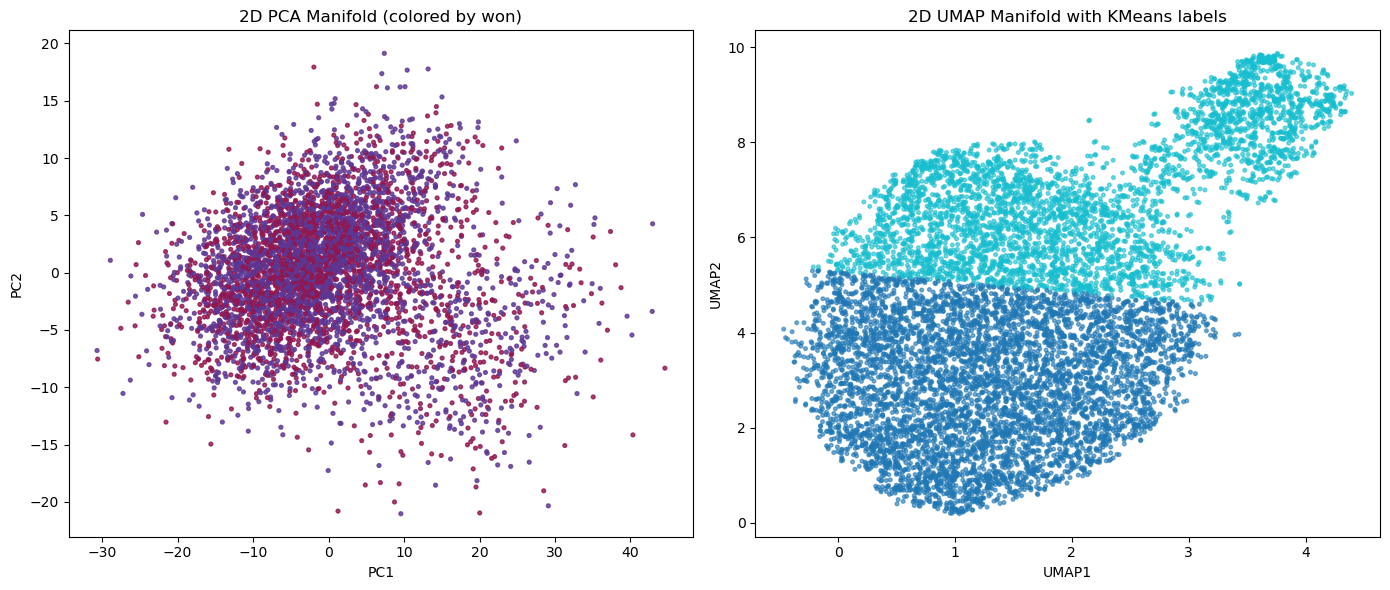

In [27]:
# Recreate the unsupervised learning outputs from the saved analysis.
pca_emb = np.load(OUTPUT_DIR / 'pca_2_embedding.npy')
umap_emb = np.load(OUTPUT_DIR / 'umap_2_embedding.npy')
train_y = train_wide['won'].to_numpy(dtype = np.int32)
cluster_scores = pd.DataFrame(results['pca_umap']['cluster_scores'])
best_k = results['pca_umap']['best_k']
kmeans = KMeans(init = 'k-means++', n_clusters = best_k, n_init = 10, random_state = RANDOM_SEED)
cluster_labels = kmeans.fit_predict(umap_emb)
display(cluster_scores)
print('PC1 variance ratio:', results['pca_umap']['pca_2_variance'][0])
print('PC2 variance ratio:', results['pca_umap']['pca_2_variance'][1])
print('90% variance components:', results['pca_umap']['n_components_90'])
print('best UMAP KMeans k:', best_k)
print('best silhouette:', results['pca_umap']['best_silhouette'])
print('cluster sizes:', results['pca_umap']['cluster_sizes'])
print('cluster win rates:', results['pca_umap']['cluster_win_rates'])
fig, axes = plt.subplots(1, 2, figsize = (14, 6))
axes[0].scatter(pca_emb[:, 0], pca_emb[:, 1], c = train_y, cmap = 'coolwarm', s = 7, alpha = 0.55)
axes[0].set_title('2D PCA Manifold (colored by won)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[1].scatter(umap_emb[:, 0], umap_emb[:, 1], c = cluster_labels, cmap = 'tab10', s = 7, alpha = 0.60)
axes[1].set_title('2D UMAP Manifold with KMeans labels')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
plt.tight_layout()
plt.show()

2. Answer:
- (a) For the exploratory data analysis, we used the widened training matrix, standardized it, and then followed the general style from our manifold/unsupervised learning class materials: PCA to summarize global variance, UMAP to build a nonlinear 2D manifold, and KMeans on the UMAP embedding. The first two principal components explained `0.104125` and `0.027617` of the variance, respectively, so the 2D PCA manifold captures some structure but not most of the total information. More information under the below questions:
- (b) To explain at least 90% of the variance, the widened training data needed `673` principal components. That is a large number, which makes sense because the sequence representation has many time, location, ownership, event-type, and situation features.
- (c) When we clustered the 2D UMAP manifold with KMeans over `k = 2` through `8`, the best silhouette score was `0.499453` at `k = 2`. So the strongest numeric answer here is that the manifold supports about `2` major clusters, not a large collection of clean isolated groups.
- (d) We would describe the manifold as having **moderate overlap/noise**. The silhouette score is only about `0.4995`, so the clusters are visible but far from perfectly separated, and the simple noise proxy `1 - silhouette` is about `0.5005`. The cluster sizes were `{'0': 4139, '1': 5747}`, and the cluster win rates were almost exactly balanced at `{'0': 0.5006040106305871, '1': 0.49956499042978947}`, which suggests the manifold is capturing broad game-style structure rather than directly separating winners from losers.

3. Question:
- (a) Detail at least two modeling architectures that you used to build a predictor.
- (b) Which one performed better?
- (c) Why do you think that is the case?

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda,gamma,objective,eval_metric,tree_method,random_state
0,445,6,0.010961,0.779599,0.667783,6,0.000463,0.273728,0.001405,binary:logistic,logloss,hist,328


,accuracy,precision,recall,f1,auc,logloss,threshold,model
0,0.771440,0.772082,0.770260,0.771170,0.889345,0.421677,0.5,xgboost_optuna
1,0.813139,0.763228,0.907946,0.829321,0.929007,0.341573,0.5,temporal_cnn


,column,sequence_position,field,gain
0,event_175_isOwner,175,isOwner,104.520882
1,event_177_isOwner,177,isOwner,101.308052
2,event_178_isOwner,178,isOwner,83.174408
3,event_173_isOwner,173,isOwner,63.255283
4,event_176_type,176,type,62.608288
5,event_159_situation,159,situation,58.144676
6,event_167_situation,167,situation,57.696136
7,event_161_situation,161,situation,52.614628
8,event_160_situation,160,situation,51.271751
9,event_158_situation,158,situation,50.319351


,won,avg_owner_share_last30
0,actual loss row,0.534304
1,actual win row,0.465696


,model,true_losses_called_losses,true_losses_called_wins,true_wins_called_losses,true_wins_called_wins
0,xgboost_optuna,982,289,292,979
1,temporal_cnn,913,358,117,1154


Top XGBoost feature positions: [158, 159, 160, 161, 167, 173, 175, 176, 177, 178]
Neural-network best validation AUC: 0.9182089567184448
Neural-network best epoch: 10
Neural-network parameter count: 9081


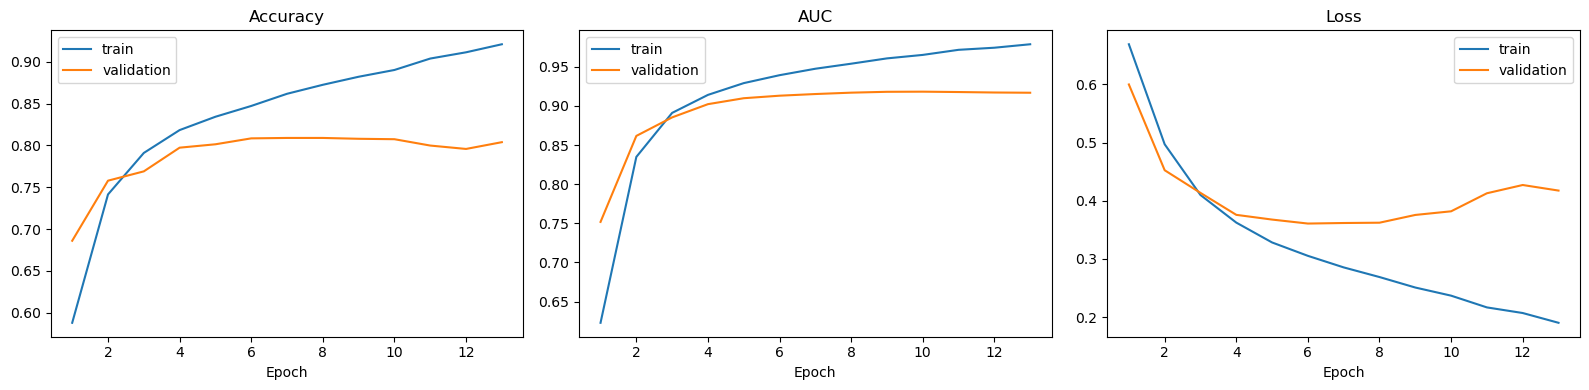

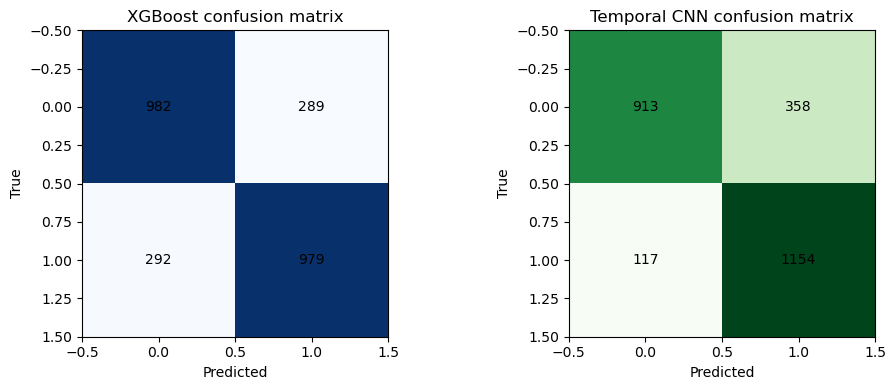

In [28]:
# Recreate the supervised modeling outputs and map them back to hockey-specific interpretation.
xgb_metrics = pd.DataFrame([results['xgboost']['test_metrics']]).drop(columns = ['confusion_matrix'])
nnn_metrics = pd.DataFrame([results['neural_network']['test_metrics']]).drop(columns = ['confusion_matrix'])
metrics_compare = pd.concat([
    xgb_metrics.assign(model = 'xgboost_optuna'),
    nnn_metrics.assign(model = 'temporal_cnn'),
], ignore_index = True)

# Translate the XGBoost feature ids into the actual widened column names.
feature_lookup = dict(enumerate(train_wide.columns))
top_feature_table = pd.DataFrame(results['xgboost']['top_gain_features'], columns = ['feature_id', 'gain'])
top_feature_table['column'] = top_feature_table['feature_id'].str[1:].astype(int).map(feature_lookup)
top_feature_table['sequence_position'] = top_feature_table['column'].str.extract(r'event_(\d+)_').astype(int)
top_feature_table['field'] = top_feature_table['column'].str.replace(r'event_\d+_', '', regex = True)

# Summarize the ownership pattern in the tail of the retained sequence.
late_owner_cols = [f'event_{i}_isOwner' for i in range(151, 181)]
late_owner_summary = (
    train_wide.groupby('won')[late_owner_cols]
    .mean()
    .mean(axis = 1)
    .rename(index = {0: 'actual loss row', 1: 'actual win row'})
    .reset_index(name = 'avg_owner_share_last30')
)

# Convert the confusion matrices into a more readable xW-style error profile.
error_rows = []
for model_name, model_key in [('xgboost_optuna', 'xgboost'), ('temporal_cnn', 'neural_network')]:
    tn, fp = results[model_key]['test_metrics']['confusion_matrix'][0]
    fn, tp = results[model_key]['test_metrics']['confusion_matrix'][1]
    error_rows.append({
        'model': model_name,
        'true_losses_called_losses': tn,
        'true_losses_called_wins': fp,
        'true_wins_called_losses': fn,
        'true_wins_called_wins': tp,
    })
error_summary = pd.DataFrame(error_rows)
display(pd.DataFrame(results['xgboost']['best_params'], index = [0]))
display(metrics_compare)
display(top_feature_table[['column', 'sequence_position', 'field', 'gain']])
display(late_owner_summary)
display(error_summary)
print('Top XGBoost feature positions:', sorted(top_feature_table['sequence_position'].tolist()))
print('Neural-network best validation AUC:', results['neural_network']['best_validation_auc'])
print('Neural-network best epoch:', results['neural_network']['best_epoch'])
print('Neural-network parameter count:', results['neural_network']['parameter_count'])
history = results['neural_network']['history']
epochs = np.arange(1, len(history['accuracy']) + 1)
fig, axes = plt.subplots(1, 3, figsize = (16, 4))
axes[0].plot(epochs, history['accuracy'], label = 'train')
axes[0].plot(epochs, history['val_accuracy'], label = 'validation')
axes[0].set_title('Accuracy')
axes[1].plot(epochs, history['auc'], label = 'train')
axes[1].plot(epochs, history['val_auc'], label = 'validation')
axes[1].set_title('AUC')
axes[2].plot(epochs, history['loss'], label = 'train')
axes[2].plot(epochs, history['val_loss'], label = 'validation')
axes[2].set_title('Loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.legend()
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 2, figsize = (10, 4))
axes[0].imshow(np.asarray(results['xgboost']['test_metrics']['confusion_matrix']), cmap = 'Blues')
axes[0].set_title('XGBoost confusion matrix')
axes[1].imshow(np.asarray(results['neural_network']['test_metrics']['confusion_matrix']), cmap = 'Greens')
axes[1].set_title('Temporal CNN confusion matrix')
for ax, cm in zip(axes, [results['xgboost']['test_metrics']['confusion_matrix'], results['neural_network']['test_metrics']['confusion_matrix']]):
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i][j], ha = 'center', va = 'center', color = 'black')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.show()


3. Answer:
- (a) We built two models. The first was an `XGBClassifier` tuned with `optuna`, where we searched over `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `reg_alpha`, `reg_lambda`, and `gamma`. The best validation AUC from that search was `0.886697`. The second was a neural-network sequence model in `keras`. For that model, we treated each row as a length-`180` ordered event sequence, embedded the categorical `event_i_type` and `event_i_situation` values, concatenated those embeddings with the numeric channels (`isOwner`, `time`, `xNorm`, `yNorm`), and then passed the sequence through a small temporal convolutional network with global max pooling. That network had `9081` trainable parameters and reached its best validation AUC of `0.918209` at epoch `10`.
- (b) The neural network performed better on the held-out `20182019` test season. The tuned XGBoost model achieved accuracy `0.7714`, precision `0.7721`, recall `0.7703`, F1 `0.7712`, AUC `0.8893`, and log-loss `0.4217`. The neural network achieved accuracy `0.8131`, precision `0.7632`, recall `0.9079`, F1 `0.8293`, AUC `0.9290`, and log-loss `0.3416`. So the neural model improved test AUC by about `0.0397`, improved test F1 by about `0.0582`, and increased recall by about `0.1377`.
- (c) The neural model won probably because it can combine ownership, event type, situation, and local order instead of treating each event position as an isolated flat column. Its confusion matrix shows `1154` true winning rows correctly identified versus `979` for XGBoost, but it also called `358` actual loss rows wins compared with `289` for XGBoost. In a normal classification problem that would just be a false-positive penalty. In this project, though, those loss rows predicted as wins are exactly the interesting candidate games where the final scoreboard may disagree with the event flow. So the temporal CNN is not just more accurate, but it is also more aligned with the xW idea of identifying teams that looked like the stronger side even when they did not get the actual result.

We wanted to leave an additional note on interpretability: The top XGBoost gain features were `event_173_isOwner`, `event_175_isOwner`, `event_177_isOwner`, `event_178_isOwner`, `event_176_type`, and late-game situation fields around events `158` through `178`. That means the flattened tree model leaned heavily on who owned the later retained events and what the strength state looked like near the end of the game. When I averaged the last 30 `isOwner` flags, rows that eventually lost actually owned a larger share of those late retained events (`0.5343`) than rows that eventually won (`0.4657`). That is a plausible score-effects signal as trailing teams often drive more late events because they are chasing the game.
